In [34]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
import scipy as sp

In [70]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/WT_500pM-HUGS_100nM-HUS_100ms_500mspf/2021-05-20_CH2-wt_100msStream')

In [71]:
dateloc = str(path).find("202")
date = str(path)[dateloc : dateloc+10]

Lifetime = 'Lifetime ' r'$(s)$'

In [72]:
def open_roi_line(name):
    roi_path = path/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [73]:
def line_dynamics(spf):
        
    data = open_roi_line('kymotrack.zip')

    n = len(data)
    pre_df = {'Date': np.full((n), date)}
    df = pd.DataFrame(pre_df) 
    
    df[Lifetime] = abs((data['y2']-data['y1'])*spf)

    return df

In [74]:
data=line_dynamics(0.1)

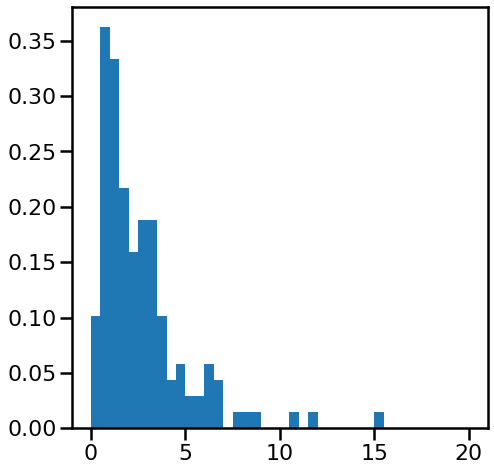

In [75]:
y=data[Lifetime]
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 20 + 0.5, 0.5), density=True);

In [76]:
def exponential(x, scale):
    return ((np.exp(-(x)/scale) )/(scale))
def equation_fit(track_duration):
    
    equation = exponential
        
    results = pd.DataFrame(columns=[] , index=[])
    
    n, bins, patches = ax.hist(track_duration, bins=np.arange(0, 150 + 1, 1), density=True);
                
    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n)

    variance = np.diagonal(var_matrix) #Refer [3]
    SE = np.sqrt(variance) #Refer [4]

            #======Making a data frame========
    results0 = pd.DataFrame(columns=[] , index=[])
    
    for k in np.arange(0,len(coeff)):
        header = [np.array(['Exponential']),np.array(['Coefficient '+ str(k)])]
        r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)
        results0 = pd.concat([results0, r0], axis=1, sort=False)

    results = pd.concat([results, results0], sort=False)

    return results

In [77]:
spf = 0.1
DCXconc=str(100)
DCXType = 'WT'

track_duration=(data[Lifetime])

EqFit = equation_fit(track_duration)

#EqFit.loc['Value'] = EqFit.loc['Value'].add((min_duration-1)*spf)

scale = EqFit['Exponential']['Coefficient 0'].loc['Value']
#x0 = EqFit['Exponential']['Coefficient 1'].loc['Value']
EqFit

,Exponential
,Coefficient 0
Value,3.491976
SE,0.092081


In [78]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
yellow = '#FFCB05'


In [79]:
true_scale = EqFit['Exponential']['Coefficient 0'].loc['Value']
SE = EqFit['Exponential']['Coefficient 0'].loc['SE']
scalestr = str(round(true_scale,1))
SEstr = str(round(SE,2))
scalestr,SEstr

('3.5', '0.09')

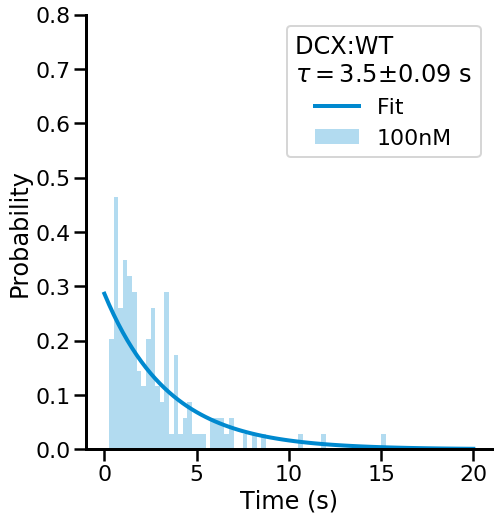

In [80]:
color=cyan
xlim = 20
bins = 0.25


x = np.arange(0, xlim + bins, bins)
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=x, density=True,color = color,alpha = 0.3);
ax.plot(x,exponential(x,scale),color = color, lw=4);
ax.set_xlabel('Time (s)')
ax.set_ylabel('Probability')
ax.set_ylim(0,0.8)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)

ax.legend(('Fit',DCXconc + 'nM'),loc='upper right',title='DCX:' + DCXType +' \n' r'$\tau = $' + scalestr + r'$\pm $'  + SEstr + ' s')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('track-duration_expo-fit.pdf'))